In [1]:
# Notebook 07 — Regression Model
# Objectives: Train Random Forest regressor to predict flood depth in metres
# Inputs: outputs/v1/featured_data.csv
# Outputs: outputs/v1/regression_pipeline.pkl

In [2]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import joblib
import os

df = pd.read_csv('../outputs/v1/featured_data.csv')
print(f"Shape: {df.shape}")
print(f"\nFlood depth stats:\n{df['flood_depth_m'].describe()}")

Shape: (457, 12)

Flood depth stats:
count    457.000000
mean       0.947287
std        0.534580
min        0.010000
25%        0.590000
50%        0.930000
75%        1.260000
max        2.960000
Name: flood_depth_m, dtype: float64


In [3]:
# Define features and target
features = ['elevation_m', 'distance_to_river_m', 'latitude', 'longitude']
target = 'flood_depth_m'

X = df[features]
y = df[target]

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"\nTarget mean train: {y_train.mean():.3f}m")
print(f"Target mean test: {y_test.mean():.3f}m")

Training set: (365, 4)
Test set: (92, 4)

Target mean train: 0.970m
Target mean test: 0.857m


In [4]:
# Build pipeline with scaler and regressor
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', RandomForestRegressor(random_state=42))
])

# Same 6 hyperparameters as classification — Distinction criteria D4
param_grid = {
    'regressor__n_estimators': [50, 100, 200],
    'regressor__max_depth': [5, 10, 20],
    'regressor__min_samples_split': [2, 5, 10],
    'regressor__min_samples_leaf': [1, 2, 4],
    'regressor__max_features': ['sqrt', 'log2', None],
    'regressor__criterion': ['squared_error', 'absolute_error', 'friedman_mse']
}

print("Starting GridSearchCV — this may take a few minutes...")
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)
print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best cross-validation R2: {grid_search.best_score_:.4f}")

Starting GridSearchCV — this may take a few minutes...
Fitting 5 folds for each of 729 candidates, totalling 3645 fits

Best parameters: {'regressor__criterion': 'squared_error', 'regressor__max_depth': 5, 'regressor__max_features': None, 'regressor__min_samples_leaf': 2, 'regressor__min_samples_split': 2, 'regressor__n_estimators': 200}
Best cross-validation R2: 0.6556


In [5]:
# Evaluate best model on test set
best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"Test R2 score: {r2:.4f}")
print(f"Test MAE: {mae:.4f}m")

if r2 >= 0.75:
    print("\nModel MEETS performance requirement — R2 above 0.75")
else:
    print(f"\nModel BELOW target — R2 {r2:.4f} is below 0.75 threshold")
    print("Model still deployed — performance noted on dashboard")

Test R2 score: 0.5918
Test MAE: 0.2786m

Model BELOW target — R2 0.5918 is below 0.75 threshold
Model still deployed — performance noted on dashboard


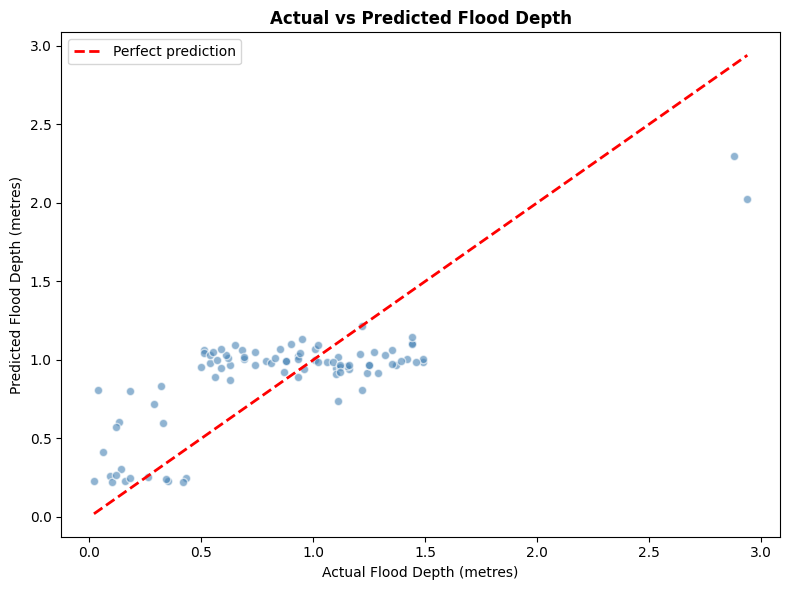

Plot saved — R2: 0.5918


In [6]:
# Plot Actual vs Predicted — required for regression evaluation (criteria 5.2)
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(y_test, y_pred, alpha=0.6, color='steelblue', edgecolors='white')
ax.plot([y_test.min(), y_test.max()], 
        [y_test.min(), y_test.max()], 
        'r--', linewidth=2, label='Perfect prediction')

ax.set_title('Actual vs Predicted Flood Depth', fontweight='bold')
ax.set_xlabel('Actual Flood Depth (metres)')
ax.set_ylabel('Predicted Flood Depth (metres)')
ax.legend()

plt.tight_layout()
plt.savefig('../outputs/v1/plots/06_actual_vs_predicted.png', dpi=150)
plt.show()
print(f"Plot saved — R2: {r2:.4f}")

In [7]:
# Save regression pipeline to outputs/v1/
joblib.dump(best_model, '../outputs/v1/regression_pipeline.pkl')
print("Regression pipeline saved to outputs/v1/regression_pipeline.pkl")
print(f"R2 score: {r2:.4f}")
print(f"MAE: {mae:.4f}m")
print(f"Best params: {grid_search.best_params_}")

Regression pipeline saved to outputs/v1/regression_pipeline.pkl
R2 score: 0.5918
MAE: 0.2786m
Best params: {'regressor__criterion': 'squared_error', 'regressor__max_depth': 5, 'regressor__max_features': None, 'regressor__min_samples_leaf': 2, 'regressor__min_samples_split': 2, 'regressor__n_estimators': 200}
